In [16]:
%load_ext autoreload
%autoreload 2
import numpy as np
import xarray as xr
import rasterio as rio
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Define the point coordinates
xpts, ypts = [457794.675537, 475697.184021, 488900.158671], [-1107613.706862, -1101544.002803, -1098954.829477]
labels = ['upstream', 'middle', 'terminus']

In [ ]:
monthly = xr.open_dataset('/Volumes/insar3/cjensen/Data/Velocity/ZI_79N_velseries_monthly.nc')
six = xr.open_dataset('/Volumes/insar3/cjensen/Data/Velocity/ZI_79N_velseries_612day.nc')
optical_ZI = xr.open_dataset('/Volumes/insar3/cjensen/Data/Velocity/ZI_79N_velseries_optical_individual_78.95N_ZI.nc')
optical_79 = xr.open_dataset('/Volumes/insar3/cjensen/Data/Velocity/ZI_79N_velseries_optical_individual_E79.40N_79N.nc')

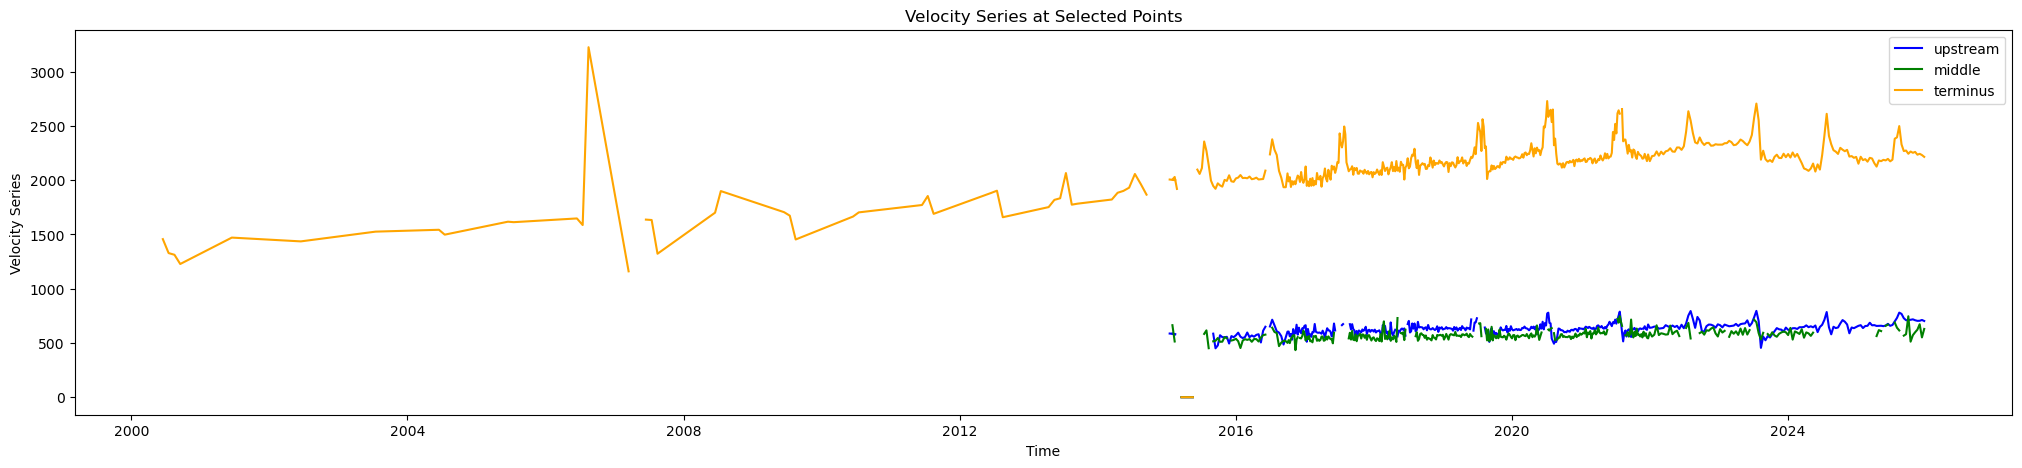

In [97]:
xpts_79 = [440000, 420000]
ypts_79 = [-1076000, -1086000]
labels_79 = ['upstream', 'terminus']

xpts, ypts = [472400, 457800, 488900], [-1107600, -1099000, -1101500]


datasets = [monthly, six, optical_ZI]
colors = ['blue', 'green', 'orange']
plt.figure(figsize=(15, 5))
for dataset in datasets:
    dataset = dataset.sel(band='vv')

    for x, y, label, color in zip( xpts, ypts, labels, colors):
        # Grab the VelocitySeries values at the specified x and y points
        selected_point = dataset.sel(x=x, y=y, method='nearest')

        # Convert the selected point DataArray to a pandas DataFrame
        df_selected_point = selected_point.to_dataframe().reset_index()
        
        plt.plot(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}', color=color)
        
        plt.xlabel('Time')
        plt.ylabel('Velocity Series')
        plt.legend(labels)
        plt.title('Velocity Series at Selected Points')
        fig = plt.gcf() # Get current figure
        fig.set_size_inches(25, 5)  
    
    # Save the DataFrame to a CSV file with the proper label
    df_selected_point.to_csv(f'/Users/cjense/Desktop/phd/Data/Raw/{label}_velocity_series_raw.csv', index=False)
    
    # plt.savefig('../figures/2_raw_velocity.png', dpi=300)

ValueError: x and y can be no greater than 2D, but have shapes (494,) and (494, 3, 1201, 801)

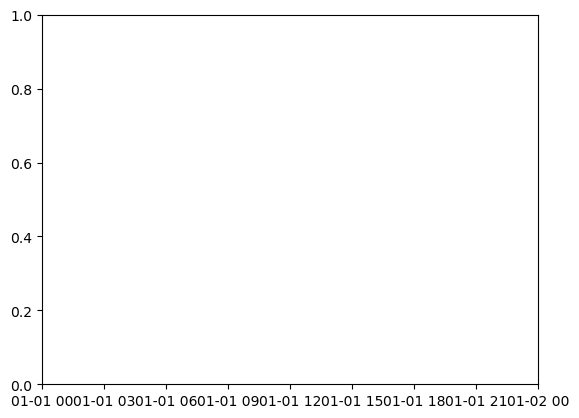

In [104]:
plt.plot(six['VelocityMap'].time, six['VelocityMap'].values)

In [110]:
six['VelocityMap']

<xarray.DataArray 'VelocityMap' (time: 494, band: 3, y: 1201, x: 801)> Size: 6GB
array([[[[  0.      , ...,   0.      ],
         ...,
         [  0.      , ...,   0.      ]],

        ...,

        [[  0.      , ...,   0.      ],
         ...,
         [  0.      , ...,   0.      ]]],


       ...,


       [[[ -2.68698 , ...,        nan],
         ...,
         [210.19885 , ...,  -4.11503 ]],

        ...,

        [[ 18.357214, ...,        nan],
         ...,
         [353.68613 , ...,   9.11722 ]]]],
      shape=(494, 3, 1201, 801), dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 4kB 2015-01-06T12:00:00 ... 2025-12-21T...
    time1       (time) datetime64[ns] 4kB 2015-01-01 2015-01-13 ... 2025-12-16
    time2       (time) datetime64[ns] 4kB 2015-01-12 2015-01-24 ... 2025-12-27
  * band        (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue  (band) float64 24B -2e+09 -2e+09 -1.0
  * y           (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x           (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name        <U4 16B 'None'
Attributes:
    grid_mapping:  spatial_ref

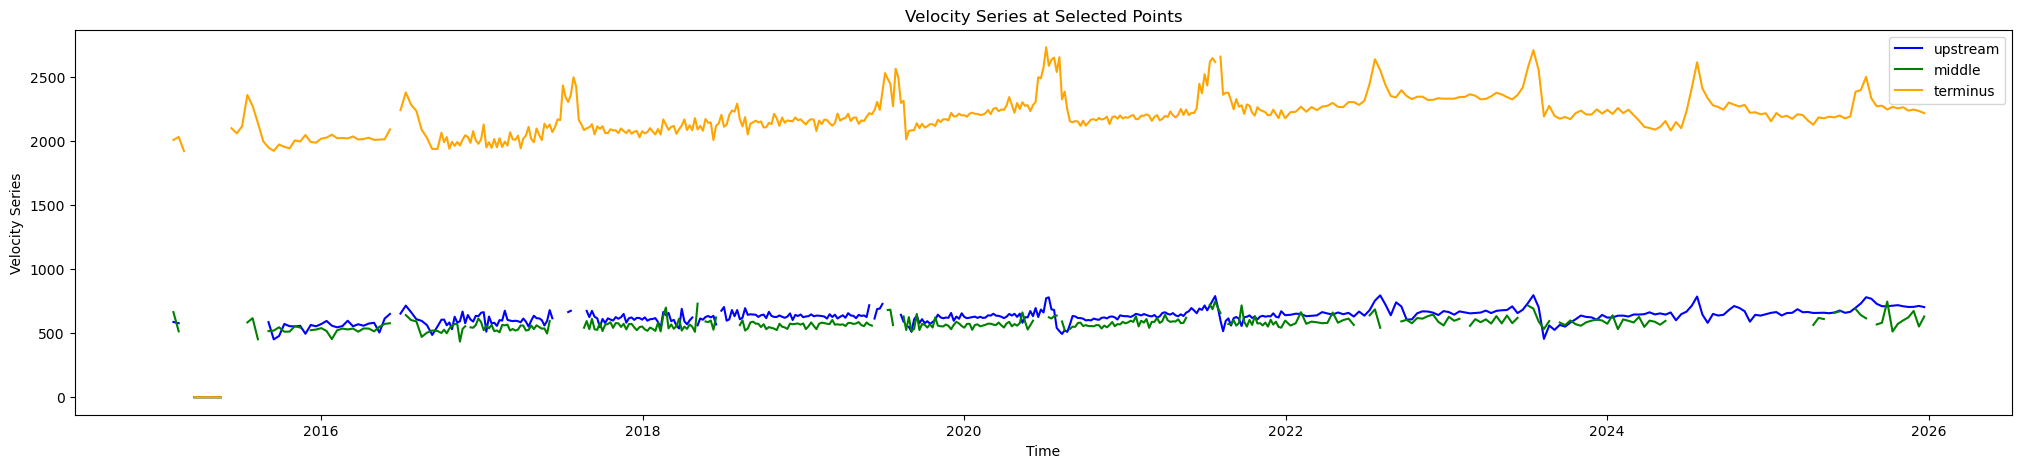

In [130]:
for x, y, label, color in zip( xpts, ypts, labels, colors):
    # Grab the VelocitySeries values at the specified x and y points
    selected_point = six['VelocityMap'].sel(band='vv').sel(x=x, y=y, method='nearest')

    # Convert the selected point DataArray to a pandas DataFrame
    df_selected_point = selected_point.to_dataframe().reset_index()
    
    plt.plot(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}', color=color)
    
    plt.xlabel('Time')
    plt.ylabel('Velocity Series')
    plt.legend(labels)
    plt.title('Velocity Series at Selected Points')
    fig = plt.gcf() # Get current figure
    fig.set_size_inches(25, 5)  

# # Save the DataFrame to a CSV file with the proper label
# df_selected_point.to_csv(f'/Users/cjense/Desktop/phd/Data/Raw/{label}_velocity_series_raw_post2015.csv', index=False)

In [139]:
df = pd.read_csv(f'/Users/cjense/Desktop/phd/Data/Raw/upstream_velocity_series_raw_post2015.csv')

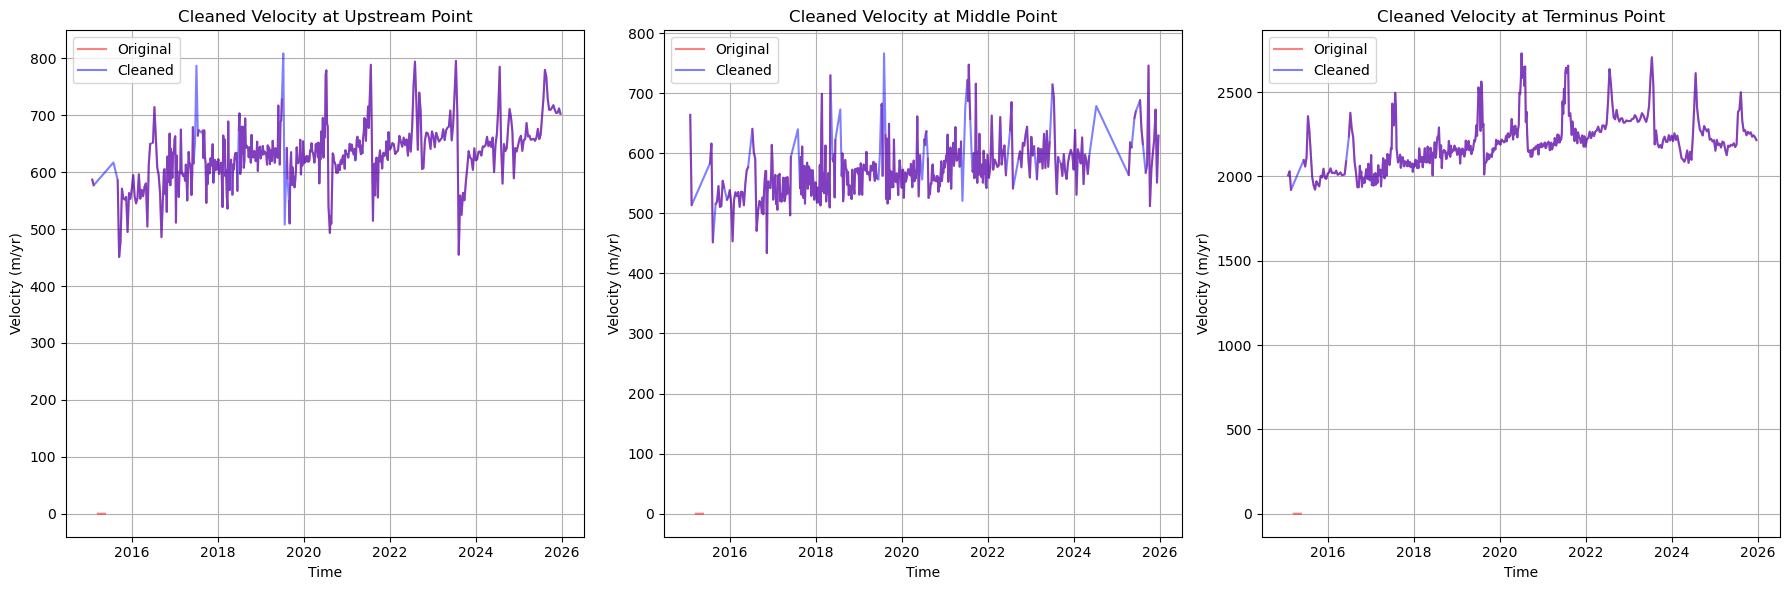

In [142]:
cleaned_velocity_series = []
cleaned_time_series = []
selected_points = []
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# for dataset in datasets:
#     # Select the 'vv' band from the dataset
#     vv = dataset.sel(band='vv')
#     vv_band = xr.Dataset()
#     vv_band = vv_band.merge(vv, join='outer')

for i, label in enumerate(labels):
    df = pd.read_csv(
        f'/Users/cjense/Desktop/phd/Data/Raw/{label}_velocity_series_raw_post2015.csv',
        parse_dates=['time']
    )

    mask = (~df['VelocityMap'].isna()) & (df['VelocityMap'] != 0)
    cleaned_velocity = df.loc[mask, 'VelocityMap'].to_numpy()
    cleaned_time = df.loc[mask, 'time'].to_numpy()

    cleaned_velocity_series.append(cleaned_velocity)
    cleaned_time_series.append(cleaned_time)
    selected_points.append(df.loc[mask, ['time', 'VelocityMap']])

    ax[i].plot(df['time'], df['VelocityMap'], color='red', alpha=0.5, label='Original')
    ax[i].plot(cleaned_time, cleaned_velocity, color='blue', alpha=0.5, label='Cleaned')

    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Velocity (m/yr)')
    ax[i].set_title(f'Cleaned Velocity at {label.capitalize()} Point')
    ax[i].legend()
    ax[i].grid(True)

    cleaned_df = pd.DataFrame({
        'time': cleaned_time,
        'VelocityMap': cleaned_velocity
    })
    cleaned_df.to_csv(
        f'/Users/cjense/Desktop/phd/Data/Clean/{label}_velocity_series_clean.csv',
        index=False
    )

# for dp, times, ds, lbl in zip(cleaned_velocity_series, cleaned_time_series, dataset_repeat, label_repeat):
#     vals = dp.values if hasattr(dp, "values") else np.asarray(dp)
#     df = pd.DataFrame({"time": pd.to_datetime(times), "VelocityMap": vals})
#     df.to_csv(f"/Users/cjense/Desktop/phd/Data/Clean/{ds}_{lbl}_velocity_series_clean.csv", index=False)


plt.tight_layout()
# plt.savefig(f'../figures/2_cleaned_velocity.png', dpi=300)
plt.show()

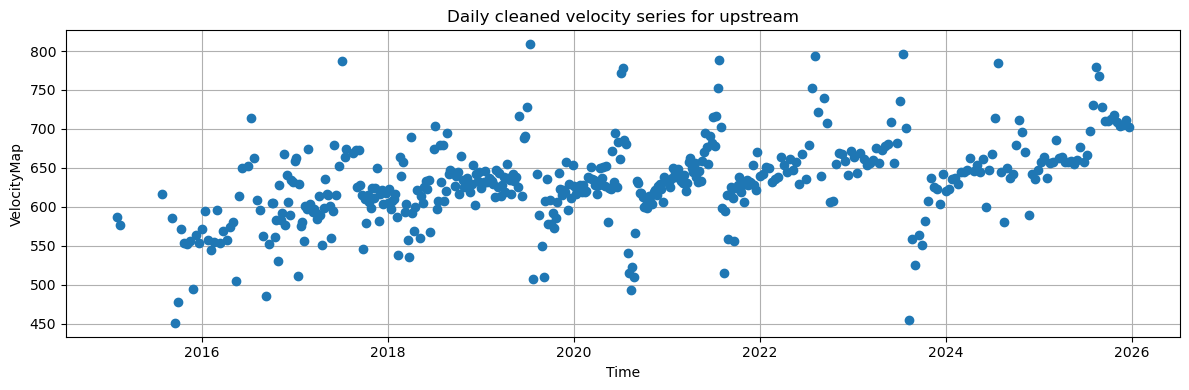

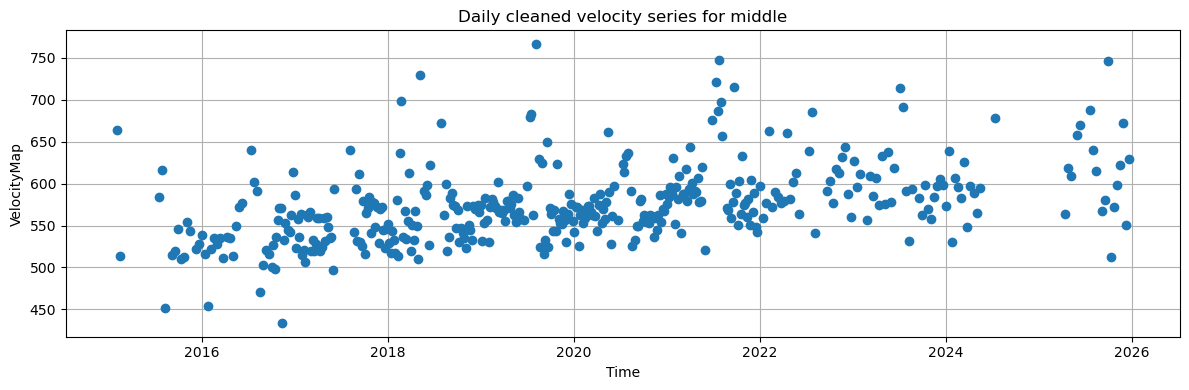

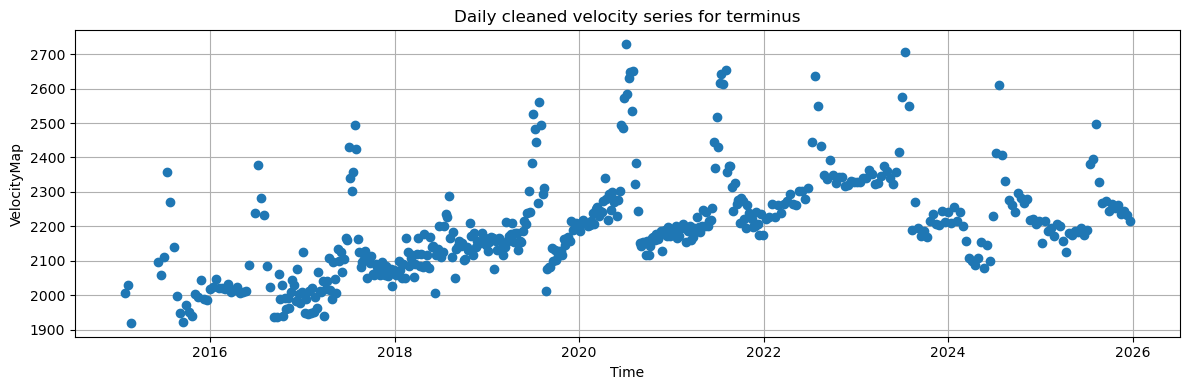

,time,VelocityMap
0,2015-01-30,586.83777
1,2015-01-31,NaN
2,2015-02-01,NaN
3,2015-02-02,NaN
4,2015-02-03,NaN


In [157]:
daily_clean_dfs = []
for label in labels:
    df_clean = pd.read_csv(
        f'/Users/cjense/Desktop/phd/Data/Clean/{label}_velocity_series_clean.csv',
        parse_dates=['time']
    ).set_index('time').sort_index()

    df_daily = df_clean.resample('D').first().reset_index()

    daily_clean_dfs.append(df_daily)

    plt.figure(figsize=(12, 4))
    plt.plot(df_daily['time'], df_daily['VelocityMap'], marker='o', linestyle='-')
    plt.title(f'Daily cleaned velocity series for {label}')
    plt.xlabel('Time')
    plt.ylabel('VelocityMap')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    df_daily.to_csv(
        # f'/Users/cjense/Desktop/phd/Data/Clean/{label}_velocity_series_clean_daily.csv',
        index=False
    )

daily_clean_dfs[0].head()

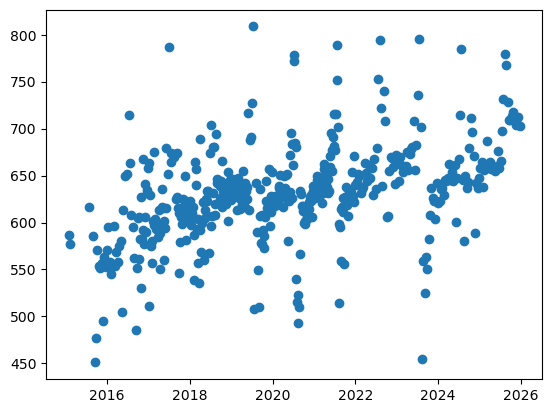

In [165]:
plt.plot(daily_clean_dfs[0].time, daily_clean_dfs[0].VelocityMap, marker='o')

In [89]:
dataset_names = ['monthly', 'six', 'optical_ZI']
dataset_repeat = dataset_names * len(labels)
# Resample each cleaned velocity series to daily values
resampled_data = []
for dp, dataset_name, label in zip(cleaned_velocity_series, dataset_repeat, labels * len(dataset_names)):
    df_temp = dp.to_dataframe().reset_index().assign(dataset=dataset_name, label=label)
    df_temp['time'] = pd.to_datetime(df_temp['time'])
    df_temp = df_temp.set_index('time').resample('D')[['VelocityMap']].mean().reset_index()
    resampled_data.append(df_temp)

merged_df = pd.concat(
    [
        dp.to_dataframe().reset_index().assign(
            dataset=dataset_name,
            label=label
        )
        for dp, dataset_name, label in zip(cleaned_velocity_series, dataset_repeat, labels * len(dataset_names))
    ],
    ignore_index=True
)

merged_df = merged_df.sort_values(['dataset', 'label', 'time']).reset_index(drop=True)
merged_df

,time,x,y,band,name,_FillValue,time1,time2,VelocityMap,dataset,label
0,2015-01-16 00:00:00,472400.0,-1107600.0,vv,None,-1.0,2015-01-01,2015-01-31,586.930786,monthly,upstream
1,2015-01-30 12:00:00,472400.0,-1107600.0,vv,None,-1.0,2015-01-25,2015-02-05,586.837769,monthly,upstream
2,2015-02-11 12:00:00,472400.0,-1107600.0,vv,None,-1.0,2015-02-06,2015-02-17,576.951172,monthly,upstream
3,2015-02-14 12:00:00,472400.0,-1107600.0,vv,None,-1.0,2015-02-01,2015-02-28,581.317810,monthly,upstream
4,2015-07-29 12:00:00,472400.0,-1107600.0,vv,None,-1.0,2015-07-24,2015-08-04,616.967224,monthly,upstream
...,...,...,...,...,...,...,...,...,...,...,...
1385,2025-11-03 12:00:00,457800.0,-1099000.0,vv,None,-1.0,2025-10-29,2025-11-09,598.851990,six,middle
1386,2025-11-15 12:00:00,457800.0,-1099000.0,vv,None,-1.0,2025-11-10,2025-11-21,622.755920,six,middle
1387,2025-11-27 12:00:00,457800.0,-1099000.0,vv,None,-1.0,2025-11-22,2025-12-03,672.741028,six,middle
1388,2025-12-09 12:00:00,457800.0,-1099000.0,vv,None,-1.0,2025-12-04,2025-12-15,551.176086,six,middle


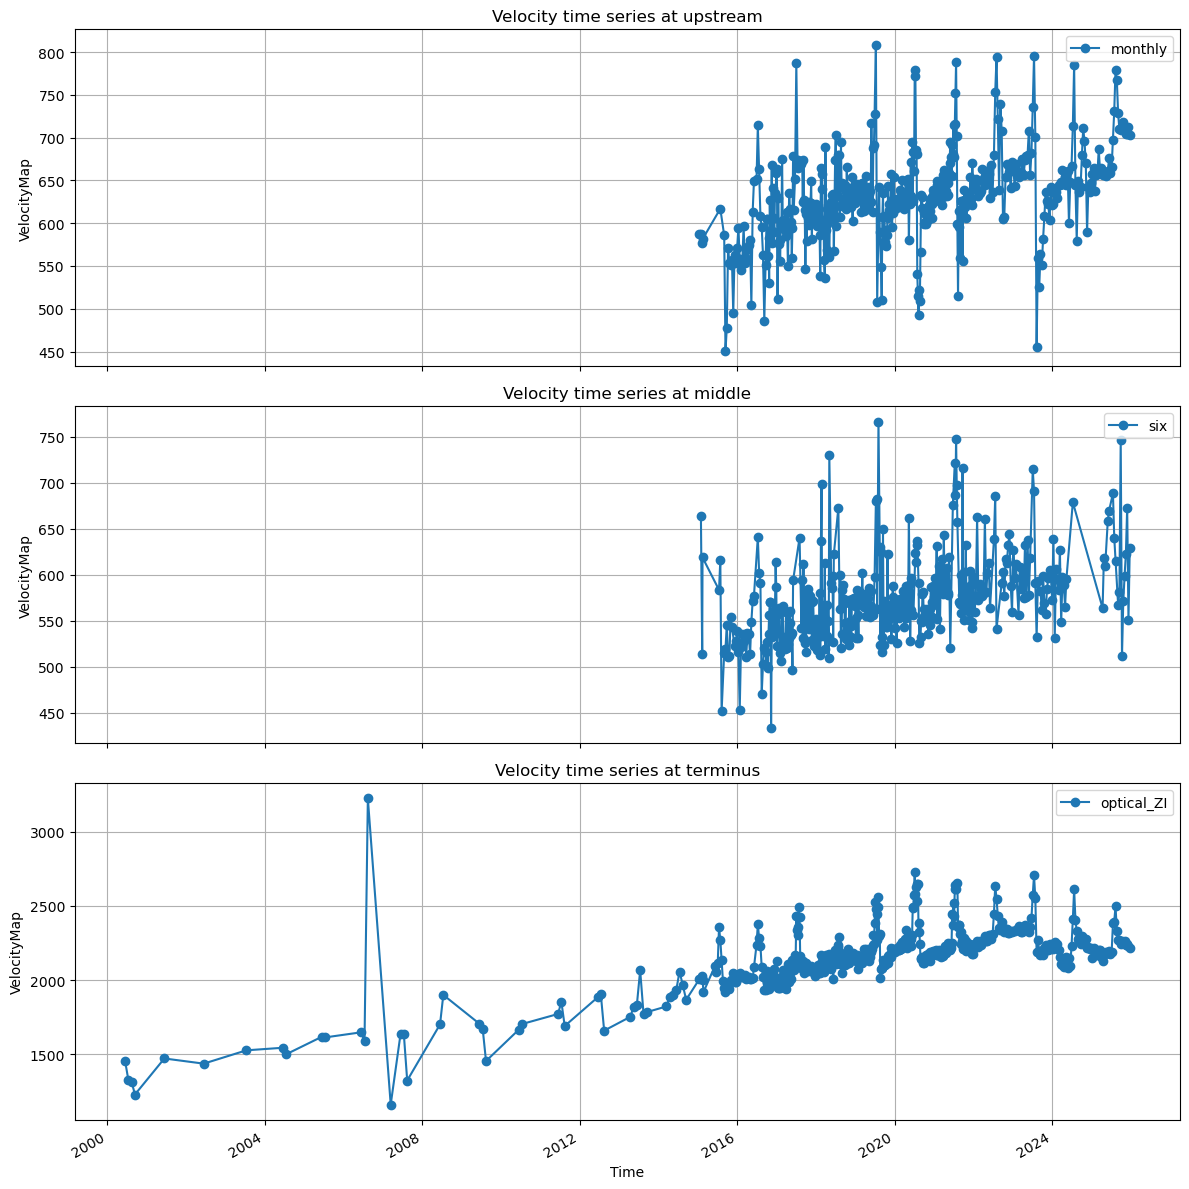

In [90]:
fig, axs = plt.subplots(len(labels), 1, figsize=(12, 4 * len(labels)), sharex=True)
if len(labels) == 1:
    axs = [axs]

for ax, label in zip(axs, labels):
    df_label = merged_df[merged_df['label'] == label]
    for dataset_name, df_ds in df_label.groupby('dataset'):
        ax.plot(df_ds['time'], df_ds['VelocityMap'], marker='o', linestyle='-', label=dataset_name)
    ax.set_title(f'Velocity time series at {label}')
    ax.set_ylabel('VelocityMap')
    ax.legend()
    ax.grid(True)

axs[-1].set_xlabel('Time')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [82]:
merged_df.to_csv('../Data/Clean/merged_velocity_ZI.csv')

In [159]:
for i, (cleaned_vel, cleaned_time, label) in enumerate(zip(cleaned_velocity_series, cleaned_time_series, labels)):
    # Create a DataFrame from the cleaned data
    df_cleaned = pd.DataFrame({
        'time': cleaned_time,
        'VelocitySeries': cleaned_vel
    })
    
    # Save the DataFrame to a CSV file with the proper label
    df_cleaned.to_csv(f'/Users/cjense/Desktop/phd/Data/Clean/{label}_velocity_series_clean.csv', index=False)

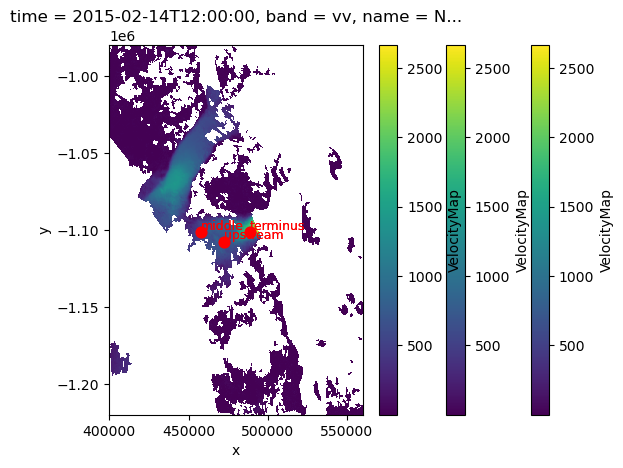

In [64]:
monthly = monthly.VelocityMap.sel(band='vv')
ax = monthly.isel(time=2).plot()
# monthly = monthly.VelocityMap.sel(band='vv')
quadmesh = monthly.isel(time=2).plot()
ax = quadmesh.axes
ax.scatter(xpts, ypts, color='red', s=60, zorder=10)

for xi, yi, lbl in zip(xpts, ypts, labels):
    ax.text(xi, yi, lbl, color='red', fontsize=9, ha='left', va='bottom')
for xi, yi, lbl in zip(xpts, ypts, labels):
    ax.text(xi, yi, lbl, color='red', fontsize=9, ha='left', va='bottom')
monthly.isel(time=2).plot()

In [78]:
optical_ZI

<xarray.Dataset> Size: 163MB
Dimensions:      (time: 45, band: 3, y: 577, x: 522)
Coordinates:
  * time         (time) datetime64[ns] 360B 2000-06-15T12:00:00 ... 2014-09-1...
    time1        (time) datetime64[ns] 360B 2000-06-01 2000-07-01 ... 2014-09-01
    time2        (time) datetime64[ns] 360B 2000-06-30 2000-07-31 ... 2014-09-30
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 5kB -1.066e+06 -1.066e+06 ... -1.124e+06 -1.124e+06
  * x            (x) float64 4kB 4.724e+05 4.725e+05 ... 5.244e+05 5.245e+05
    name         <U4 16B 'None'
Data variables:
    spatial_ref  int64 8B 0
    VelocityMap  (time, band, y, x) float32 163MB ...

In [107]:
dataset['time'][-1] < pd.to_datetime('2006-01-01')

<xarray.DataArray 'time' ()> Size: 1B
array(False)
Coordinates:
    time     datetime64[ns] 8B 2014-09-15T12:00:00
    name     <U4 16B 'None'
    time1    datetime64[ns] 8B 2014-09-01
    time2    datetime64[ns] 8B 2014-09-30

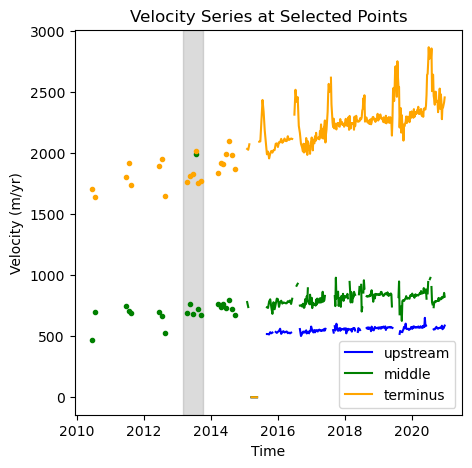

In [115]:
xpts_79 = [440000, 420000]
ypts_79 = [-1076000, -1086000]
labels_79 = ['upstream', 'terminus']

datasets = [six, optical_ZI]
colors = ['blue', 'green', 'orange']

for dataset in datasets:
    dataset_sel = dataset.sel(band='vv')

    for x, y, label, color in zip(xpts, ypts, labels, colors):
        # Grab the VelocitySeries values at the specified x and y points
        selected_point = dataset_sel.sel(x=x, y=y, method='nearest')

        # Convert the selected point DataArray to a pandas DataFrame
        df_selected_point = selected_point.to_dataframe().reset_index()
        
        # Filter data from 2010-2025
        df_selected_point = df_selected_point[
            (df_selected_point['time'] >= '2010-01-01') &
            (df_selected_point['time'] <= '2020-12-31')
        ]
        
        # if dataset['time'][-1] < pd.to_datetime('2006-01-01'):
        #     not_six = True
        # else:
        #     not_six = False
        
        cutoff = pd.Timestamp("2015-01-01")
        df_pre = df_selected_point[df_selected_point['time'] < cutoff]
        df_post = df_selected_point[df_selected_point['time'] >= cutoff]

        if not df_pre.empty:
            # plt.plot(df_pre['time'], df_pre['VelocityMap'], label=f'x: {x}, y: {y}', color=color)
            plt.scatter(df_pre['time'], df_pre['VelocityMap'], color=color, marker='.')
        if not df_post.empty:
            plt.plot(df_post['time'], df_post['VelocityMap'], label=f'x: {x}, y: {y}', color=color)
        # plt.scatter(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}', color=color, marker='.')
        
        plt.xlabel('Time')
        plt.ylabel('Velocity (m/yr)')
        plt.legend(labels)
        plt.title('Velocity Series at Selected Points')
        fig = plt.gcf() # Get current figure
        fig.set_size_inches(5, 5)
    
    start = pd.Timestamp("2013-03-01")
    end = pd.Timestamp("2013-09-30")
    plt.axvspan(start, end, color='Gray', alpha=0.15, zorder=0)
    # Save the DataFrame to a CSV file with the proper label
    # df_selected_point.to_csv(f'/Users/cjense/Desktop/phd/Data/Raw/{label}_velocity_series_raw.csv', index=False)
    
    # plt.savefig('../figures/2_raw_velocity.png', dpi=300)

In [23]:
for dataset in datasets:
    # Select the 'vv' band from the dataset
    vv = dataset.sel(band='vv')
    
    vv_band = vv_band.merge(vv, join='outer')

NameError: name 'vv_band' is not defined

NameError: name 'vv_band' is not defined

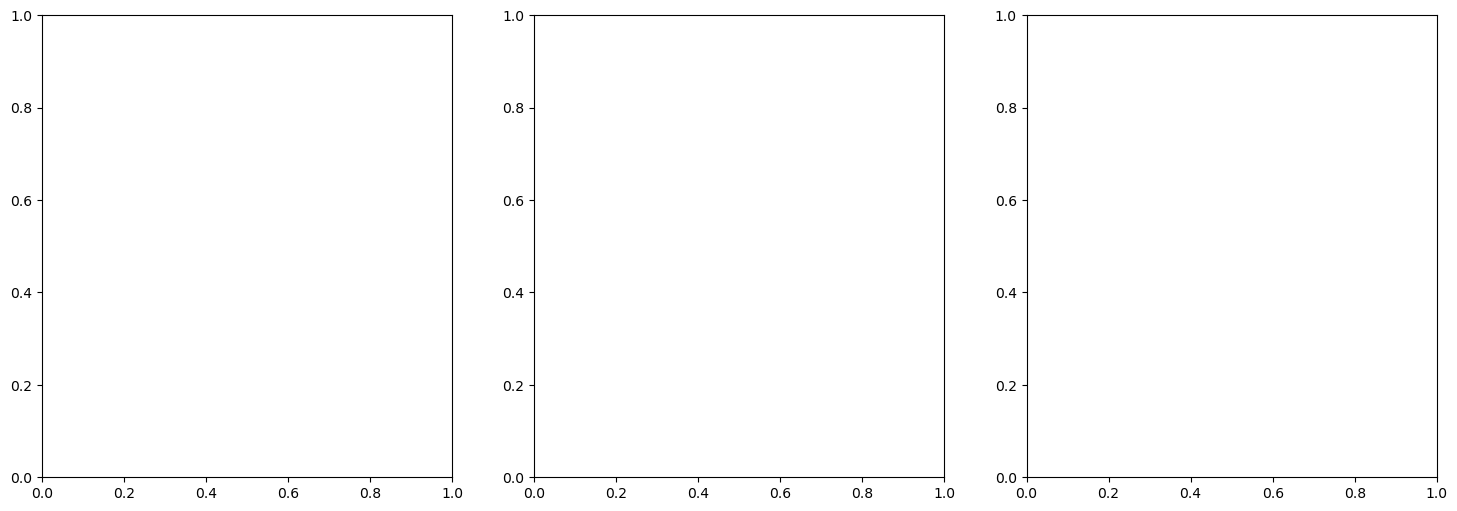

In [ ]:
cleaned_velocity_series = []
cleaned_time_series = []
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
for i, (x, y, label) in enumerate(zip(xpts, ypts, labels)):

    # Grab the VelocitySeries values at the specified x and y points
    selected_point = vv_band['VelocityMap'].sel(x=x, y=y, method='nearest')

    # Drop NaNs from the array and corresponding time values
    mask = ~np.isnan(selected_point) & (selected_point != 0)
    cleaned_velocity = selected_point[mask]
    cleaned_time = vv_band.time.values[mask]

    cleaned_velocity_series.append(cleaned_velocity)
    cleaned_time_series.append(cleaned_time)

    # Plot the cleaned data with the original data
    ax[i].plot(vv_band.time, selected_point, color='red', alpha=0.5, label='Original')
    ax[i].plot(cleaned_time, cleaned_velocity, color='blue', alpha=0.5, label='Cleaned')

    # Label the plot
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Velocity (m/yr)')
    ax[i].set_title(f'Cleaned Velocity at {label.capitalize()} Point')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
# plt.savefig(f'../figures/2_cleaned_velocity.png', dpi=300)
plt.show()

In [ ]:
for i, (cleaned_vel, cleaned_time, label) in enumerate(zip(cleaned_velocity_series, cleaned_time_series, labels)):
    # Create a DataFrame from the cleaned data
    df_cleaned = pd.DataFrame({
        'time': cleaned_time,
        'VelocitySeries': cleaned_vel
    })
    
    # Save the DataFrame to a CSV file with the proper label
    # df_cleaned.to_csv(f'/Users/cjense/Desktop/phd/Data/Clean/{label}_velocity_series_clean.csv', index=False)

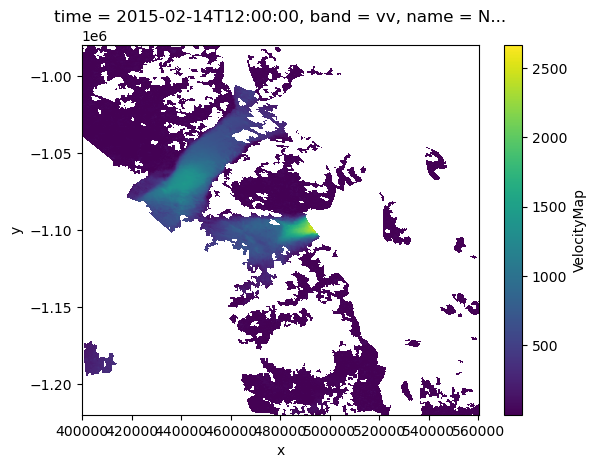

In [29]:
monthly_map = monthly.VelocityMap.sel(band='vv')
monthly_map.isel(time=2).plot()

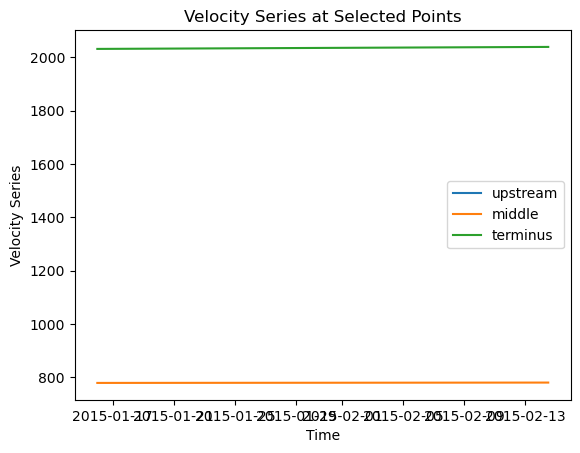

In [30]:
monthly_ts = monthly.sel(band='vv')

for x, y, label in zip(xpts, ypts, labels):

    # Grab the VelocitySeries values at the specified x and y points
    selected_point = monthly_ts.sel(x=x, y=y, method='nearest')

    # Convert the selected point DataArray to a pandas DataFrame
    df_selected_point = selected_point.to_dataframe().reset_index()
        
    plt.plot(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}')
    
    plt.xlabel('Time')
    plt.ylabel('Velocity Series')
    plt.legend(labels)
    plt.title('Velocity Series at Selected Points')
    
    # Save the DataFrame to a CSV file with the proper label
    # df_selected_point.to_csv(f'../data/raw/{label}_velocity_series_raw.csv', index=False)
    
    # plt.savefig('../figures/2_raw_velocity.png', dpi=300)

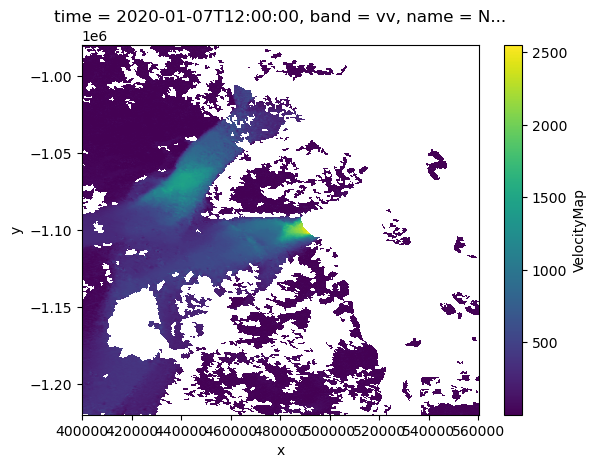

In [31]:
six_map = six.VelocityMap.sel(band='vv')
six_map.isel(time=252).plot()

In [32]:
six_ts = six.sel(band='vv')

for x, y, label in zip(xpts, ypts, labels):

    # Grab the VelocitySeries values at the specified x and y points
    selected_point = six_ts.sel(x=x, y=y, method='nearest')

    # Convert the selected point DataArray to a pandas DataFrame
    df_selected_point = selected_point.to_dataframe().reset_index()
    
    plt.plot(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}')
    
    plt.xlabel('Time')
    plt.ylabel('Velocity Series')
    plt.legend(labels)
    plt.title('Velocity Series at Selected Points')
    fig = plt.gcf() # Get current figure
    fig.set_size_inches(20, 5)  
    
    # Save the DataFrame to a CSV file with the proper label
    # df_selected_point.to_csv(f'../data/raw/{label}_velocity_series_raw.csv', index=False)
    
    # plt.savefig('../figures/2_raw_velocity.png', dpi=300)

KeyError: "not all values found in index 'x'. Try setting the `method` keyword argument (example: method='nearest')."

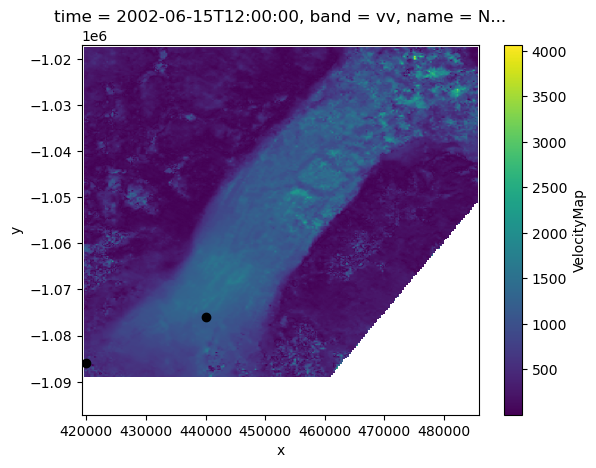

In [40]:
optical_79_map = optical_79.VelocityMap.sel(band='vv')
optical_79_map.isel(time=6).plot()

plt.scatter(xpts_79, ypts_79, marker='o', color="Black")

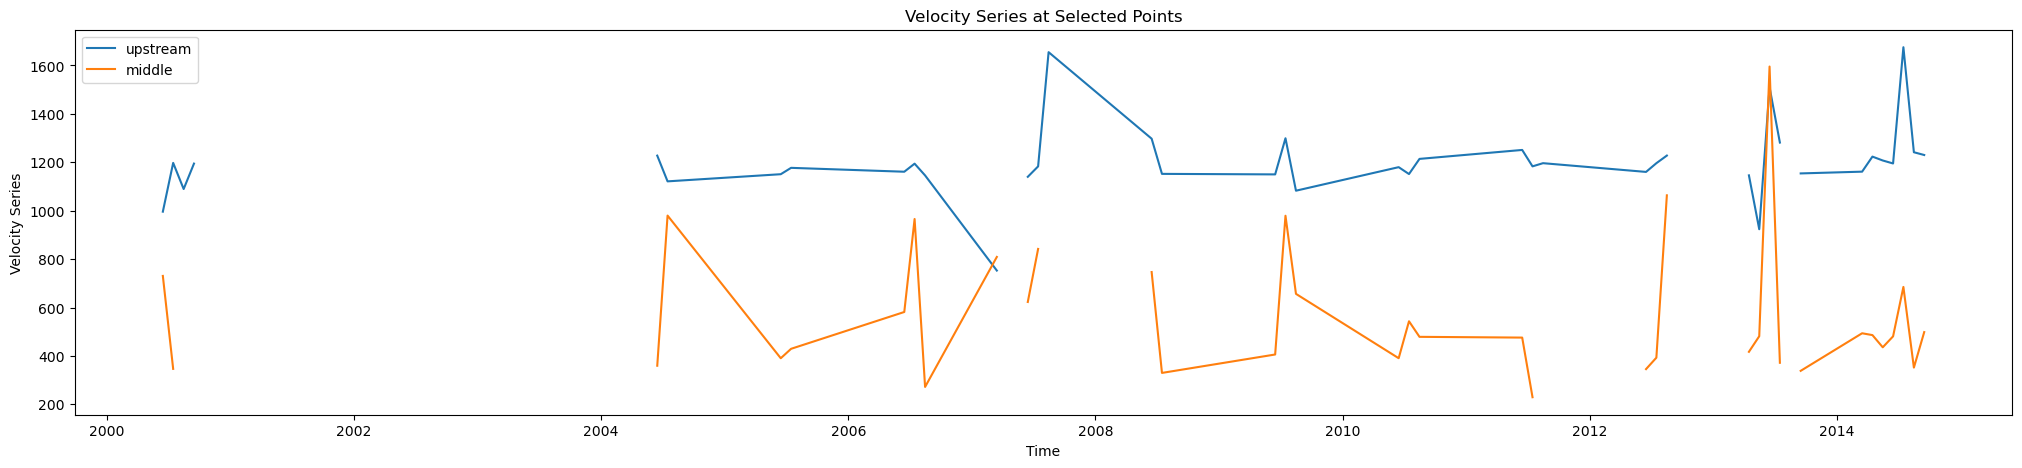

In [41]:
xpts_79 = [440000, 420000]
ypts_79 = [-1076000, -1086000]
labels_79 = ['upstream', 'terminus']

optical_79_ts = optical_79.sel(band='vv')

for x, y, label in zip(xpts_79, ypts_79, labels_79):

    # Grab the VelocitySeries values at the specified x and y points
    selected_point = optical_79_ts.sel(x=x, y=y, method='nearest')

    # Convert the selected point DataArray to a pandas DataFrame
    df_selected_point = selected_point.to_dataframe().reset_index()
    
    plt.plot(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}')
    
    plt.xlabel('Time')
    plt.ylabel('Velocity Series')
    plt.legend(labels)
    plt.title('Velocity Series at Selected Points')
    fig = plt.gcf() # Get current figure
    fig.set_size_inches(25, 5)  
    
    # Save the DataFrame to a CSV file with the proper label
    # df_selected_point.to_csv(f'../data/raw/{label}_velocity_series_raw.csv', index=False)
    
    # plt.savefig('../figures/2_raw_velocity.png', dpi=300)

In [14]:
optical_ZI_map = optical_ZI.VelocityMap.sel(band='vv')
optical_ZI_map.isel(time=37).plot()

# optical_ZI_mean = optical_ZI.VelocityMap.mean(dim='time')
# optical_ZI_mean.sel(band='vv').plot()

plt.scatter(xpts, ypts, color="Black", marker='o')

NameError: name 'optical_ZI' is not defined

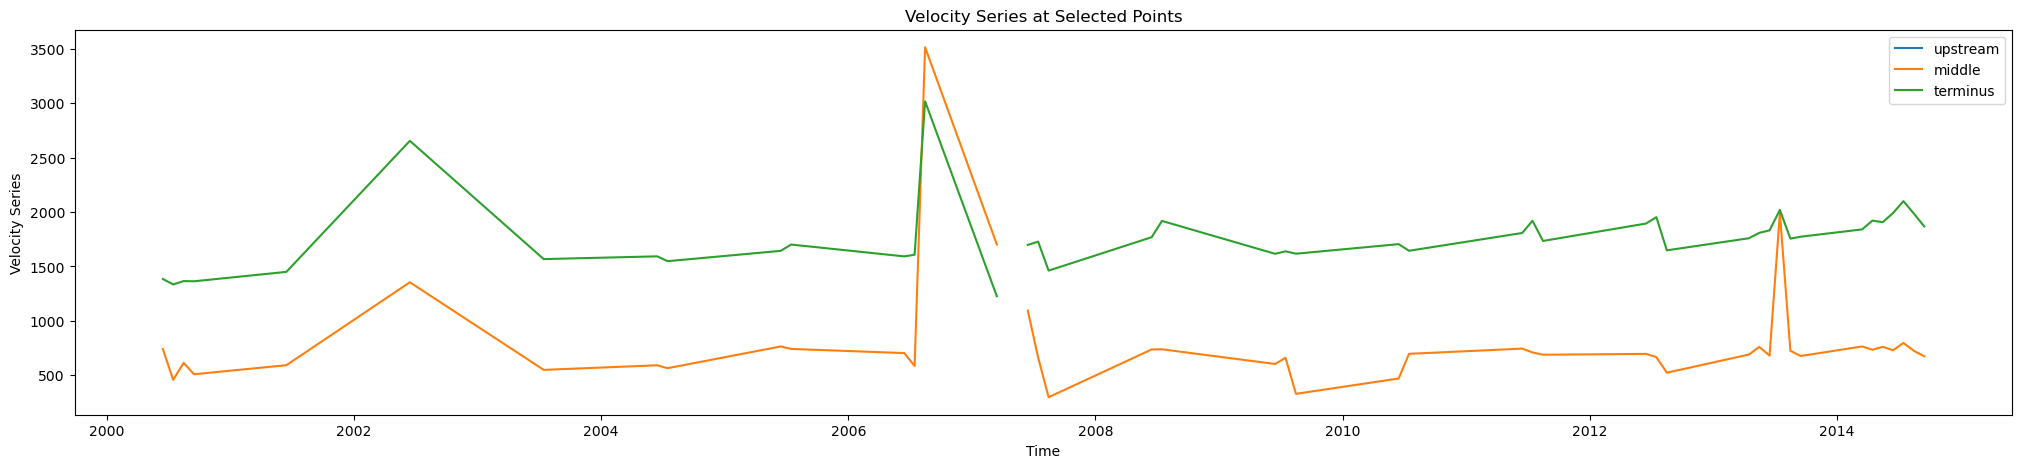

In [43]:
optical_ZI_ts = optical_ZI.sel(band='vv')

for x, y, label in zip(xpts, ypts, labels):

    # Grab the VelocitySeries values at the specified x and y points
    selected_point = optical_ZI_ts.sel(x=x, y=y, method='nearest')

    # Convert the selected point DataArray to a pandas DataFrame
    df_selected_point = selected_point.to_dataframe().reset_index()
    
    plt.plot(df_selected_point['time'], df_selected_point['VelocityMap'], label=f'x: {x}, y: {y}')
    
    plt.xlabel('Time')
    plt.ylabel('Velocity Series')
    plt.legend(labels)
    plt.title('Velocity Series at Selected Points')
    fig = plt.gcf() # Get current figure
    fig.set_size_inches(25, 5)  
    
    # Save the DataFrame to a CSV file with the proper label
    # df_selected_point.to_csv(f'../data/raw/{label}_velocity_series_raw.csv', index=False)
    
    # plt.savefig('../figures/2_raw_velocity.png', dpi=300)